# Economic False Bastions: Minimum Wage vs. Party (a state-level cut)

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory narrative
over the project's data; a quick state-level cut before any county ingest.*

## The question

We've measured "False Bastions" on *social* issues (abortion): red places that
vote more progressively than their party predicts. Does the same thing happen
on an *economic* issue — minimum wage? And does it follow the intuitive story
(poorer places want a raise) or the famous counter-story, **"What's the Matter
with Kansas?"** (poor conservative places vote *against* their economic
interest)?

Minimum wage is the ideal probe: a clean yes/no economic question, voted on in
~32 statewide measures since 1996. Here we take the **state level** first — no
county ingest — pairing each measure's Yes share with that state's presidential
**partisan lean**, computed from our own county returns. "Economic dissonance"
is the same idea as the abortion work, on the economic axis:

> economic_dissonance = minimum-wage Yes share − state Democratic two-party share

Positive = the state voted *more* for the raise than its presidential vote would
predict — an **economic False Bastion**.

## The bottom line (plain language)

**On a direct economic ballot question, self-interest crosses party — hardest
in the poorest red states.** Deep-red, lower-income states (Arkansas, Missouri,
Nebraska, South Dakota) passed minimum-wage hikes by 55–76%, *far* above
their ~37–45% Democratic presidential share — the largest economic dissonance in
the set. Bluer, richer states (Colorado, Washington) sit close to their partisan
lean. So this *inverts* "What's the Matter with Kansas": when the economic
question is put directly — stripped of party label and candidate — red-state
voters back it decisively. The ballot reveals an economic disposition their
party vote completely masks.

**Honest limits:** a verified subset (10 measures, 2006–2020, where we could
confirm the Yes share), state-level (ecological), and selection-biased (minimum
wage is *on* the ballot mostly where it's likely to pass). This is a signal
check, not a model — but the signal is strong and one-directional.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
DATA = ROOT / "web/public/data"

# Verified statewide minimum-wage INCREASE measures (Yes %, sourced from
# Ballotpedia / contemporaneous reporting). Each carries the presidential year
# used for its partisan baseline (the election on or just before the measure).
# A verified subset of the ~32 measures since 1996 — 1996 (MO/MT) predates our
# returns; a few recent ones are omitted where we did not confirm the exact Yes%.
# Alaska's 2014 measure is omitted too: Alaska reports presidential results by
# district, not county, so it has no partisan baseline in our county panel.
MEASURES = pd.DataFrame(
    [
        ("MO", "29", 2006, 75.9, 2004),
        ("AR", "05", 2014, 65.0, 2012),
        ("NE", "31", 2014, 59.0, 2012),
        ("SD", "46", 2014, 55.0, 2012),
        ("AZ", "04", 2016, 59.1, 2016),
        ("CO", "08", 2016, 54.3, 2016),
        ("ME", "23", 2016, 55.6, 2016),
        ("WA", "53", 2016, 59.5, 2016),
        ("MO", "29", 2018, 62.3, 2016),
        ("FL", "12", 2020, 60.8, 2020),
    ],
    columns=["state", "state_fips", "year", "yes_pct", "baseline_year"],
)
MEASURES["yes_share"] = MEASURES["yes_pct"] / 100.0

## State partisan lean from our own county returns

For each measure, sum the county presidential votes in its state for the
baseline year and take the Democratic two-party share — the same `metrics_*`
data products the live map serves.

In [2]:
def state_dem_two_party(state_fips: str, year: int) -> float:
    metrics = json.loads((DATA / f"metrics_{year}.json").read_text())
    dem = rep = 0.0
    for fips, m in metrics.items():
        if fips.startswith(state_fips) and m.get("dem_votes") is not None:
            dem += m["dem_votes"]
            rep += m["rep_votes"]
    return dem / (dem + rep)


MEASURES["dem_2p"] = [
    state_dem_two_party(r.state_fips, r.baseline_year) for r in MEASURES.itertuples()
]
MEASURES["economic_dissonance"] = MEASURES["yes_share"] - MEASURES["dem_2p"]
MEASURES.sort_values("economic_dissonance", ascending=False).round(3)

,state,state_fips,year,yes_pct,baseline_year,yes_share,dem_2p,economic_dissonance
0,MO,29,2006,75.9,2004,0.759,0.449,0.310
1,AR,05,2014,65.0,2012,0.650,0.378,0.272
8,MO,29,2018,62.3,2016,0.623,0.383,0.240
2,NE,31,2014,59.0,2012,0.590,0.389,0.201
3,SD,46,2014,55.0,2012,0.550,0.408,0.142
9,FL,12,2020,60.8,2020,0.608,0.483,0.125
4,AZ,04,2016,59.1,2016,0.591,0.481,0.110
6,ME,23,2016,55.6,2016,0.556,0.514,0.042
5,CO,08,2016,54.3,2016,0.543,0.527,0.016
7,WA,53,2016,59.5,2016,0.595,0.588,0.007


## Does economic self-interest cross party? (the headline)

If minimum-wage support just tracked partisanship, the points would sit on the
diagonal and dissonance would be ~0. The "Kansas" story predicts red states
*below* the diagonal. The self-interest story predicts red states *above* it.

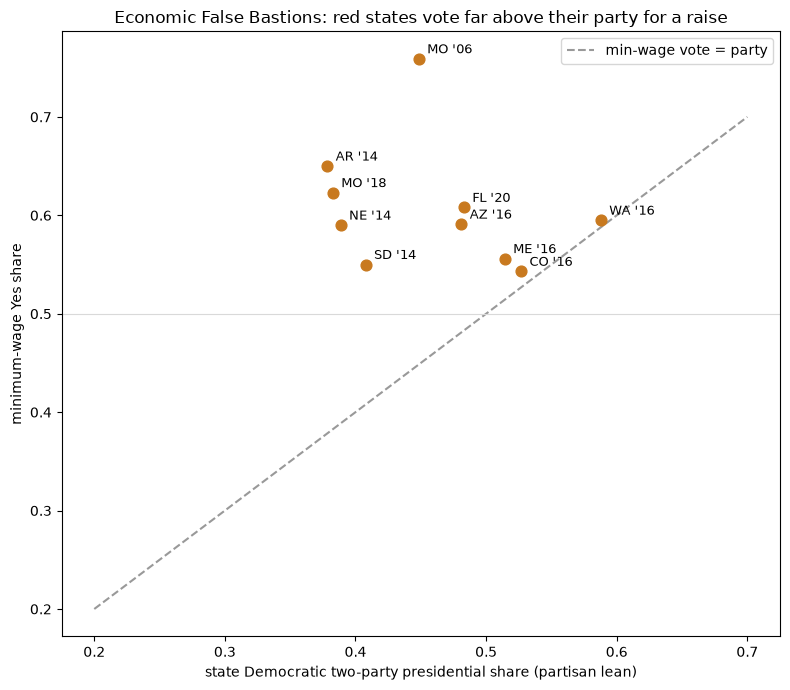

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(MEASURES["dem_2p"], MEASURES["yes_share"], s=60, color="#C8791F", zorder=3)
for r in MEASURES.itertuples():
    ax.annotate(
        f"{r.state} '{str(r.year)[2:]}",
        (r.dem_2p, r.yes_share),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
    )
ax.plot([0.2, 0.7], [0.2, 0.7], ls="--", color="0.6", label="min-wage vote = party")
ax.axhline(0.5, color="0.85", lw=0.8)
ax.set_xlabel("state Democratic two-party presidential share (partisan lean)")
ax.set_ylabel("minimum-wage Yes share")
ax.set_title("Economic False Bastions: red states vote far above their party for a raise")
ax.legend()
fig.tight_layout()
plt.show()

In [4]:
corr = MEASURES["dem_2p"].corr(MEASURES["economic_dissonance"])
print(f"corr(partisan lean, economic dissonance) = {corr:.2f}")
print(f"mean economic dissonance = {MEASURES['economic_dissonance'].mean():+.3f}")
print(f"every measure has positive dissonance: {(MEASURES['economic_dissonance'] > 0).all()}")
print("\nbiggest economic False Bastions (voted most above their partisan lean):")
top = MEASURES.nlargest(5, "economic_dissonance")[
    ["state", "year", "yes_share", "dem_2p", "economic_dissonance"]
]
print(top.round(3).to_string(index=False))

corr(partisan lean, economic dissonance) = -0.82
mean economic dissonance = +0.147
every measure has positive dissonance: True

biggest economic False Bastions (voted most above their partisan lean):
state  year  yes_share  dem_2p  economic_dissonance
   MO  2006      0.759   0.449                0.310
   AR  2014      0.650   0.378                0.272
   MO  2018      0.623   0.383                0.240
   NE  2014      0.590   0.389                0.201
   SD  2014      0.550   0.408                0.142


## The income angle (secondary, static snapshot)

Per-capita-weighted state median household income (2024 ACS, from the same
metrics product) vs. economic dissonance. Static income applied to older
measures — a rough read only — but it shows whether the dissonance concentrates
in poorer states.

In [5]:
metrics24 = json.loads((DATA / "metrics_2024.json").read_text())


def state_income(state_fips: str) -> float:
    num = den = 0.0
    for fips, m in metrics24.items():
        if fips.startswith(state_fips) and m.get("median_hh_income") and m.get("total_population"):
            num += m["median_hh_income"] * m["total_population"]
            den += m["total_population"]
    return num / den


MEASURES["state_income"] = [state_income(r.state_fips) for r in MEASURES.itertuples()]
income_corr = MEASURES["state_income"].corr(MEASURES["economic_dissonance"])
print(f"corr(state income, economic dissonance) = {income_corr:.2f}")
MEASURES.sort_values("state_income")[
    ["state", "year", "state_income", "dem_2p", "yes_share", "economic_dissonance"]
].round(3)

corr(state income, economic dissonance) = -0.78


,state,year,state_income,dem_2p,yes_share,economic_dissonance
1,AR,2014,59953.912,0.378,0.650,0.272
0,MO,2006,70532.836,0.449,0.759,0.310
8,MO,2018,70532.836,0.383,0.623,0.240
3,SD,2014,71969.463,0.408,0.550,0.142
9,FL,2020,72372.859,0.483,0.608,0.125
6,ME,2016,73436.730,0.514,0.556,0.042
2,NE,2014,76111.041,0.389,0.590,0.201
4,AZ,2016,77969.765,0.481,0.591,0.110
5,CO,2016,94509.843,0.527,0.543,0.016
7,WA,2016,97732.546,0.588,0.595,0.007


## What this shows

*(The honest read, from the executed numbers above.)*

**Economic self-interest crosses party — and it's strongest in the poorest red
states.** All 10 measures passed *above* their state's Democratic presidential
share (positive economic dissonance throughout, mean +15 points), and the
dissonance is *largest* exactly where the partisan lean is *lowest*: the
correlation between partisan lean and economic dissonance is **−0.82**. Missouri
(+31 in 2006, +24 in 2018), Arkansas (+27), and Nebraska (+20) voted for a raise
20–30 points above their presidential Democratic share; blue Colorado (+2) and
Washington (+1) sit essentially *on* their partisan line. The redder and poorer
the state, the harder it crossed party for the raise.

**This inverts "What's the Matter with Kansas."** The thesis says poor
conservatives vote against their economic interest — and at the *presidential*
level they appear to. But put the economic question *directly* on the ballot,
stripped of party and candidate, and those same voters back it decisively. The
party vote was masking an economic disposition the ballot measure reveals — the
exact "issues show what party hides" pattern we found on abortion, now on the
economic axis and pointing the other ideological direction.

**It also reframes the value of geospatial/issue analytics one more time:** the
stable, readable signal isn't *party* (a swappable label) — it's *disposition*,
and disposition is multi-dimensional. A county or state can be socially one way
and economically another; only direct issue votes expose that cross-pressure,
and the cross-pressured places are exactly where minds are movable.

**Honest limits.** N = 10 verified measures (2006–2020); state-level and so
ecological (a within-state county cut — Florida 2020, Missouri 2018 — is the
natural next step and where the gradient would sharpen); selection bias (minimum
wage reaches the ballot mostly where it can win, which compresses the Yes range
and inflates the average); and a static 2024 income snapshot applied to older
measures. A signal check, strong and one-directional — not yet a model.